# A7 — Model Evaluation

In this notebook, we evaluate the forecasting models using a train-test split.

## Objective
The goal is to compare model performance on unseen data and identify the most suitable forecasting method for the JFK passenger time series.

## Evaluation Strategy

We use the last 24 months as the test set.

The models are trained only on the training data and then evaluated on the test period.

This simulates a real-world forecasting scenario where future observations are unknown.

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv('../data/air-passenger-traffic-per-month-port-authority-of-ny-nj-beginning-1977.csv')

df_jfk = df[df['Airport Code'] == 'JFK'].copy()

df_jfk['Date'] = pd.to_datetime(
    df_jfk['Year'].astype(str) + '-' + df_jfk['Month'] + '-01'
)

ts = df_jfk.groupby('Date')['Total Passengers'].sum().sort_index()

ts.head(10)

Date
1977-01-01    1487588
1977-02-01    1237719
1977-03-01    1450395
1977-04-01    1609159
1977-05-01    1724392
1977-06-01    1906396
1977-07-01    2373334
1977-08-01    2372987
1977-09-01    2010979
1977-10-01    1806198
Name: Total Passengers, dtype: int64

In [4]:
## Checking the Time Series

# Before splitting the data, we check the structure of the time series.

print(ts.head())
print(ts.tail())
print(ts.index.is_unique)
print(ts.isna().sum())


Date
1977-01-01    1487588
1977-02-01    1237719
1977-03-01    1450395
1977-04-01    1609159
1977-05-01    1724392
Name: Total Passengers, dtype: int64
Date
2015-08-01    5809724
2015-09-01    4782097
2015-10-01    4900066
2015-11-01    4342058
2015-12-01    4697493
Name: Total Passengers, dtype: int64
True
0


In [5]:
## Train - Test Split 

train = ts[:-24]
test = ts[-24:]

print('Train Size:', train.shape)
print('Test Size:', test.shape)
print(train.tail())
print(test.head())


Train Size: (444,)
Test Size: (24,)
Date
2013-08-01    5088447
2013-09-01    4210409
2013-10-01    4209188
2013-11-01    3717622
2013-12-01    4295150
Name: Total Passengers, dtype: int64
Date
2014-01-01    3732908
2014-02-01    3240578
2014-03-01    4134490
2014-04-01    4410994
2014-05-01    4688566
Name: Total Passengers, dtype: int64


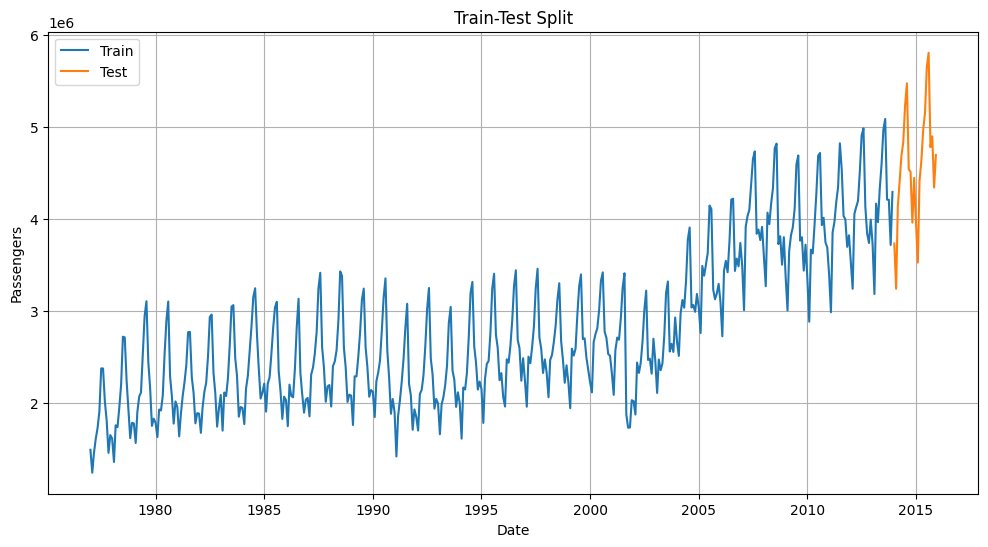

In [6]:
plt.figure(figsize=(12,6))

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.title('Train-Test Split')
plt.xlabel('Date')
plt.ylabel('Passengers')

plt.legend()
plt.grid(True)
plt.show()

## Model Training and Forecasting

In this section, we train three forecasting models on the training data:

- Simple Exponential Smoothing (SES)
- Holt’s Linear Trend Method
- Holt-Winters Method

Each model is trained only on the training set and then used to forecast the test period.

In [9]:
# Simple Ecponential Smoothing 

ses_model = SimpleExpSmoothing(train).fit()
ses_forecast = ses_model.forecast(len(test))

# Holt's Linear Trend Method 
holt_model = Holt(train).fit()
holt_forecast = holt_model.forecast(len(test))

# Holt-winters Method 
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit()

hw_forecast = hw_model.forecast(len(test))

# Holt-Winters Additive
hw_add_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

hw_add_forecast = hw_add_model.forecast(len(test))

c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

models = {
    'SES': ses_forecast,
    'Holt': holt_forecast,
    'Holt-Winters' : hw_forecast

}

for name, pred in models.items():
    mae, rmse = evaluate(test, pred)
    print(f'{name} -> MAE: {mae: .2f}, RMSE: {rmse: .2f}')


SES -> MAE:  558855.50, RMSE:  687845.44
Holt -> MAE:  493593.45, RMSE:  625907.36
Holt-Winters -> MAE:  177578.89, RMSE:  215119.80


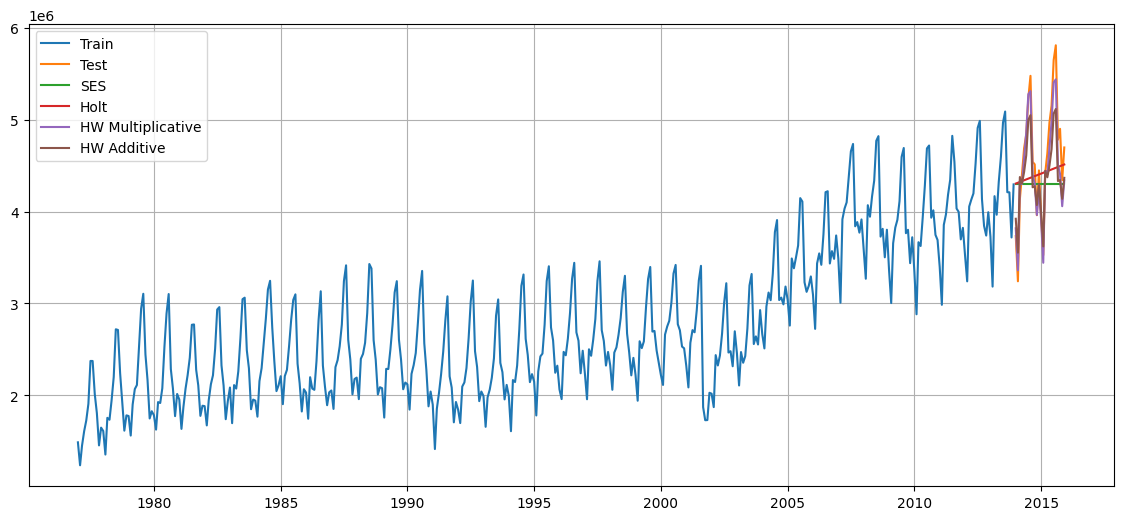

In [10]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.plot(ses_forecast, label='SES')
plt.plot(holt_forecast, label='Holt')
plt.plot(hw_forecast, label='HW Multiplicative')
plt.plot(hw_add_forecast, label='HW Additive')

plt.legend()
plt.grid()
plt.show()

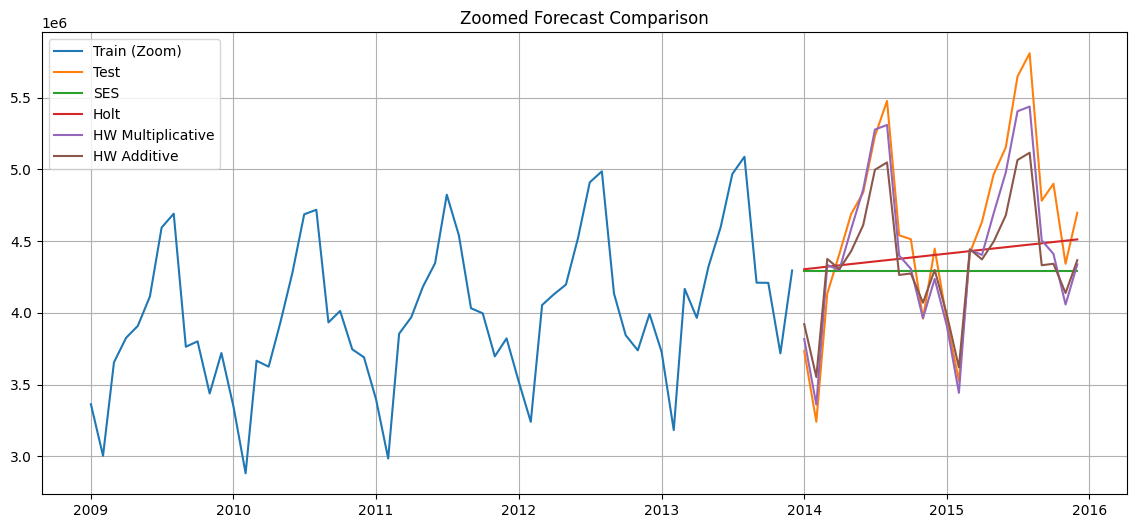

In [11]:
plt.figure(figsize=(14,6))

# sadece son 60 ayı göster (train + test)
zoom_train = train[-60:]

plt.plot(zoom_train, label='Train (Zoom)')
plt.plot(test, label='Test')

plt.plot(ses_forecast, label='SES')
plt.plot(holt_forecast, label='Holt')
plt.plot(hw_forecast, label='HW Multiplicative')
plt.plot(hw_add_forecast, label='HW Additive')

plt.title('Zoomed Forecast Comparison')
plt.legend()
plt.grid()
plt.show()

## Model Comparison (Zoomed Analysis)

A closer look at the test period shows clear differences between models:

- SES produces a nearly flat forecast and fails to capture both trend and seasonality.
- Holt’s method captures the trend but fails to model seasonal fluctuations.
- Holt-Winters additive captures seasonality but underestimates increasing seasonal variation.
- Holt-Winters multiplicative captures both the trend and the increasing seasonal fluctuations effectively.

The multiplicative model provides the closest fit to the actual data, especially around peak and low demand periods.

Therefore, the Holt-Winters multiplicative model is considered the most appropriate model for this dataset.

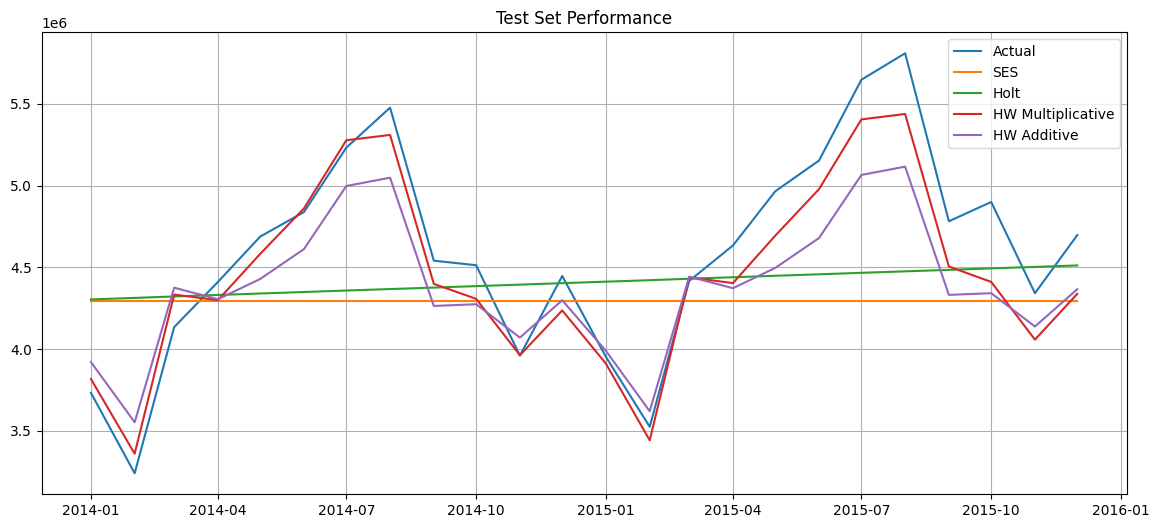

In [12]:
plt.figure(figsize=(14,6))

plt.plot(test, label='Actual')

plt.plot(ses_forecast, label='SES')
plt.plot(holt_forecast, label='Holt')
plt.plot(hw_forecast, label='HW Multiplicative')
plt.plot(hw_add_forecast, label='HW Additive')

plt.title('Test Set Performance')
plt.legend()
plt.grid()
plt.show()

##Merticlerin hesaplanması 

In [13]:
def MAD(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def MSE(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def MAPE(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [14]:
models = {
    'SES': ses_forecast,
    'Holt': holt_forecast,
    'HW_Multiplicative': hw_forecast,
    'HW_Additive': hw_add_forecast

}


In [16]:
results = []

for name, pred, in models.items():
    mad = MAD(test, pred)
    mse = MSE(test, pred)
    mape = MAPE(test, pred)

    results.append([name, mad, mse, mape])

results_df = pd.DataFrame(results, columns=['Model', 'MAD', 'MSE', 'MAPE'])
results_df = results_df.sort_values(by='MAPE')

results_df

,Model,MAD,MSE,MAPE
2,HW_Multiplicative,177578.888714,4.627653e+10,3.782718
3,HW_Additive,289665.131923,1.140085e+11,6.092932
1,Holt,493593.454496,3.917600e+11,10.800252
0,SES,558855.504303,4.731314e+11,12.013572


## Final Model Selection

The performance of all models was evaluated using MAD, MSE, and MAPE.

The results clearly indicate that:

- The Holt-Winters multiplicative model has the lowest error across all evaluation metrics.
- This confirms that the model successfully captures both trend and increasing seasonal variation in the data.
- Other models either fail to capture seasonality (SES, Holt) or assume constant seasonal variation (additive model), which leads to higher errors.

Therefore, the Holt-Winters multiplicative model is selected as the most appropriate forecasting model for this dataset.

Additionally, the superiority of the multiplicative model is consistent with the visual analysis, where seasonal fluctuations increase as the level of the series increases.